In [9]:
# Setup and Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

# Add project root to python path so 'src' can be imported easily
sys.path.insert(0, os.path.abspath('..'))

from src.preprocessing import load_data, handle_missing_values

# Setup output dir
DATA_DIR = os.path.join(os.path.abspath('..'), "data")
OUTPUT_DIR = os.path.join(os.path.abspath('..'), "outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (12, 7)


In [10]:
# 1. Load Transformed Relational Dataset
df = load_data(DATA_DIR)
df = handle_missing_values(df)
print(f"Total Closed Deals: {df.shape[0]}")
df.head(3)


✅ Master dataset compiled: 6711 closed deals × 10 features
Total Closed Deals: 6711


,sales_agent,product,account,sector,year_established,revenue,employees,office_location,IsWon,sales_cycle_duration_days
0,Moses Frase,GTX Plus Basic,Cancity,retail,2001.0,718.62,2448.0,United States,1,132
1,Darcel Schlecht,GTXPro,Isdom,medical,2002.0,3178.24,4540.0,United States,1,137
2,Darcel Schlecht,MG Special,Cancity,retail,2001.0,718.62,2448.0,United States,1,133


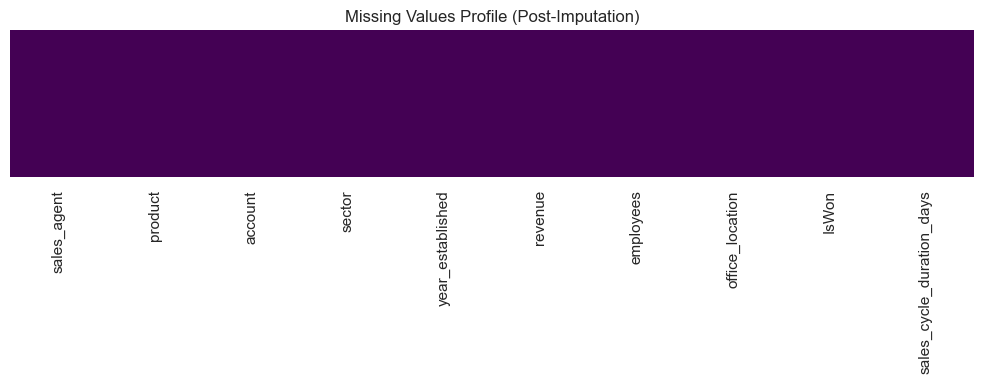

In [11]:
# 2. Missing Values Heatmap Check
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Profile (Post-Imputation)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'missing_values_profile.png'))
plt.show()


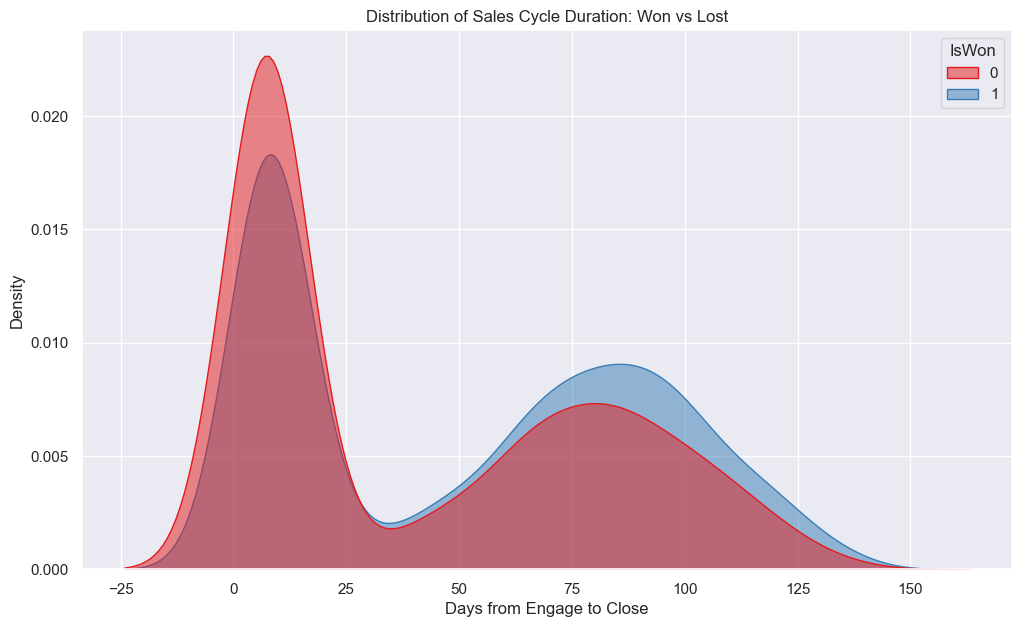

In [12]:
# 3. Kernel Density of Sales Cycle Duration by Outcome
plt.figure()
sns.kdeplot(data=df, x='sales_cycle_duration_days', hue='IsWon', 
            fill=True, common_norm=False, palette='Set1', alpha=0.5)
plt.title('Distribution of Sales Cycle Duration: Won vs Lost')
plt.xlabel('Days from Engage to Close')
plt.savefig(os.path.join(OUTPUT_DIR, 'duration_kde.png'))
plt.show()


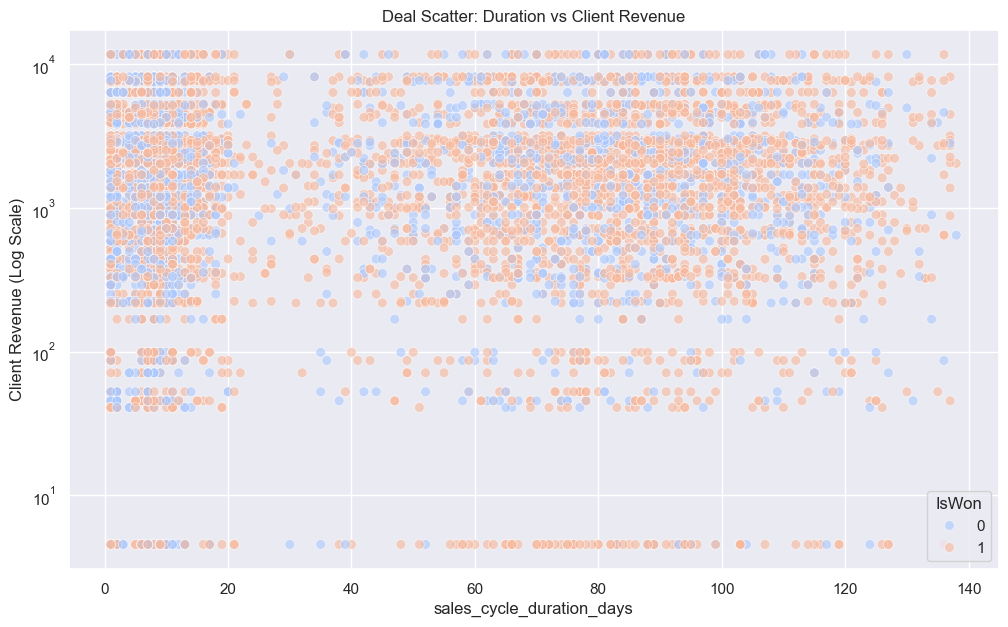

In [13]:
# 4. Joint Relationship: Revenue vs Duration 
plt.figure()
sns.scatterplot(data=df, x='sales_cycle_duration_days', y='revenue', hue='IsWon', 
                palette='coolwarm', alpha=0.6, s=50)
plt.title('Deal Scatter: Duration vs Client Revenue')
plt.yscale('log') # Log scale for revenue given corporate disparities
plt.ylabel('Client Revenue (Log Scale)')
plt.savefig(os.path.join(OUTPUT_DIR, 'revenue_vs_duration_scatter.png'))
plt.show()


/var/folders/hd/q1w8z_m13kbd90cpsgpq744h0000gn/T/ipykernel_46293/121887618.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(agent_stats.index, rotation=45, ha='right')


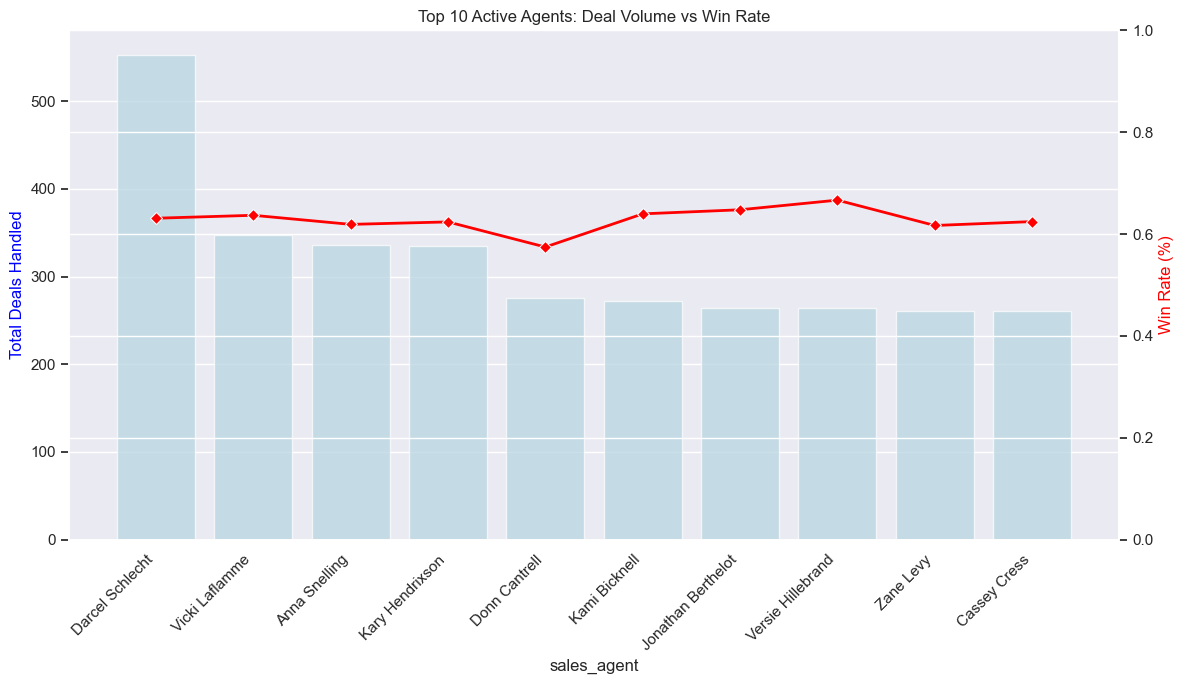

In [14]:
# 5. Top 10 Sales Agents by Deal Volume and their Win Rates
agent_stats = df.groupby('sales_agent').agg(
    Total_Deals=('IsWon', 'count'),
    Win_Rate=('IsWon', 'mean')
).sort_values(by='Total_Deals', ascending=False).head(10)

fig, ax1 = plt.subplots()

# Plot Volume
sns.barplot(x=agent_stats.index, y=agent_stats['Total_Deals'], ax=ax1, color='lightblue', alpha=0.7)
ax1.set_ylabel('Total Deals Handled', color='blue')
ax1.set_xticklabels(agent_stats.index, rotation=45, ha='right')

# Plot Win Rate
ax2 = ax1.twinx()
sns.lineplot(x=agent_stats.index, y=agent_stats['Win_Rate'], ax=ax2, color='red', marker='D', linewidth=2)
ax2.set_ylabel('Win Rate (%)', color='red')
ax2.set_ylim(0, 1)

plt.title('Top 10 Active Agents: Deal Volume vs Win Rate')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'top_agents_win_rates.png'))
plt.show()
